In [93]:
words = open('names.txt', 'r').read().splitlines()

In [94]:
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [95]:
len(words)

32033

In [96]:
min(len(w) for w in words), max(len(w) for w in words)

(2, 15)

In [97]:
b = {}
for w in words:
    for ch1, ch2 in zip('.' + w, w + '.'):
        if (ch1, ch2) not in b:
            b[ch1, ch2] = 0
        else:
            b[ch1, ch2] += 1
        # print(ch1, ch2) 

In [98]:
b

{('.', 'e'): 1530,
 ('e', 'm'): 768,
 ('m', 'm'): 167,
 ('m', 'a'): 2589,
 ('a', '.'): 6639,
 ('.', 'o'): 393,
 ('o', 'l'): 618,
 ('l', 'i'): 2479,
 ('i', 'v'): 268,
 ('v', 'i'): 910,
 ('i', 'a'): 2444,
 ('.', 'a'): 4409,
 ('a', 'v'): 833,
 ('v', 'a'): 641,
 ('.', 'i'): 590,
 ('i', 's'): 1315,
 ('s', 'a'): 1200,
 ('a', 'b'): 540,
 ('b', 'e'): 654,
 ('e', 'l'): 3247,
 ('l', 'l'): 1344,
 ('l', 'a'): 2622,
 ('.', 's'): 2054,
 ('s', 'o'): 530,
 ('o', 'p'): 94,
 ('p', 'h'): 203,
 ('h', 'i'): 728,
 ('.', 'c'): 1541,
 ('c', 'h'): 663,
 ('h', 'a'): 2243,
 ('a', 'r'): 3263,
 ('r', 'l'): 412,
 ('l', 'o'): 691,
 ('o', 't'): 117,
 ('t', 't'): 373,
 ('t', 'e'): 715,
 ('e', '.'): 3982,
 ('.', 'm'): 2537,
 ('m', 'i'): 1255,
 ('a', 'm'): 1633,
 ('m', 'e'): 817,
 ('.', 'h'): 873,
 ('r', 'p'): 13,
 ('p', 'e'): 196,
 ('e', 'r'): 1957,
 ('r', '.'): 1376,
 ('e', 'v'): 462,
 ('v', 'e'): 567,
 ('l', 'y'): 1587,
 ('y', 'n'): 1825,
 ('n', '.'): 6762,
 ('b', 'i'): 216,
 ('i', 'g'): 427,
 ('g', 'a'): 329,
 ('a',

In [99]:
sorted(b.items(), key=lambda x: x[1], reverse=True)[:10]

[(('n', '.'), 6762),
 (('a', '.'), 6639),
 (('a', 'n'), 5437),
 (('.', 'a'), 4409),
 (('e', '.'), 3982),
 (('a', 'r'), 3263),
 (('e', 'l'), 3247),
 (('r', 'i'), 3032),
 (('n', 'a'), 2976),
 (('.', 'k'), 2962)]

In [100]:
!pip install torch

In [101]:
import torch

In [102]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [103]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

In [104]:
for w in words:
    for ch1, ch2 in zip('.' + w, w + '.'):
        N[stoi[ch1], stoi[ch2]] += 1

In [105]:
!pip install matplotlib

In [106]:
!pip install numpy

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

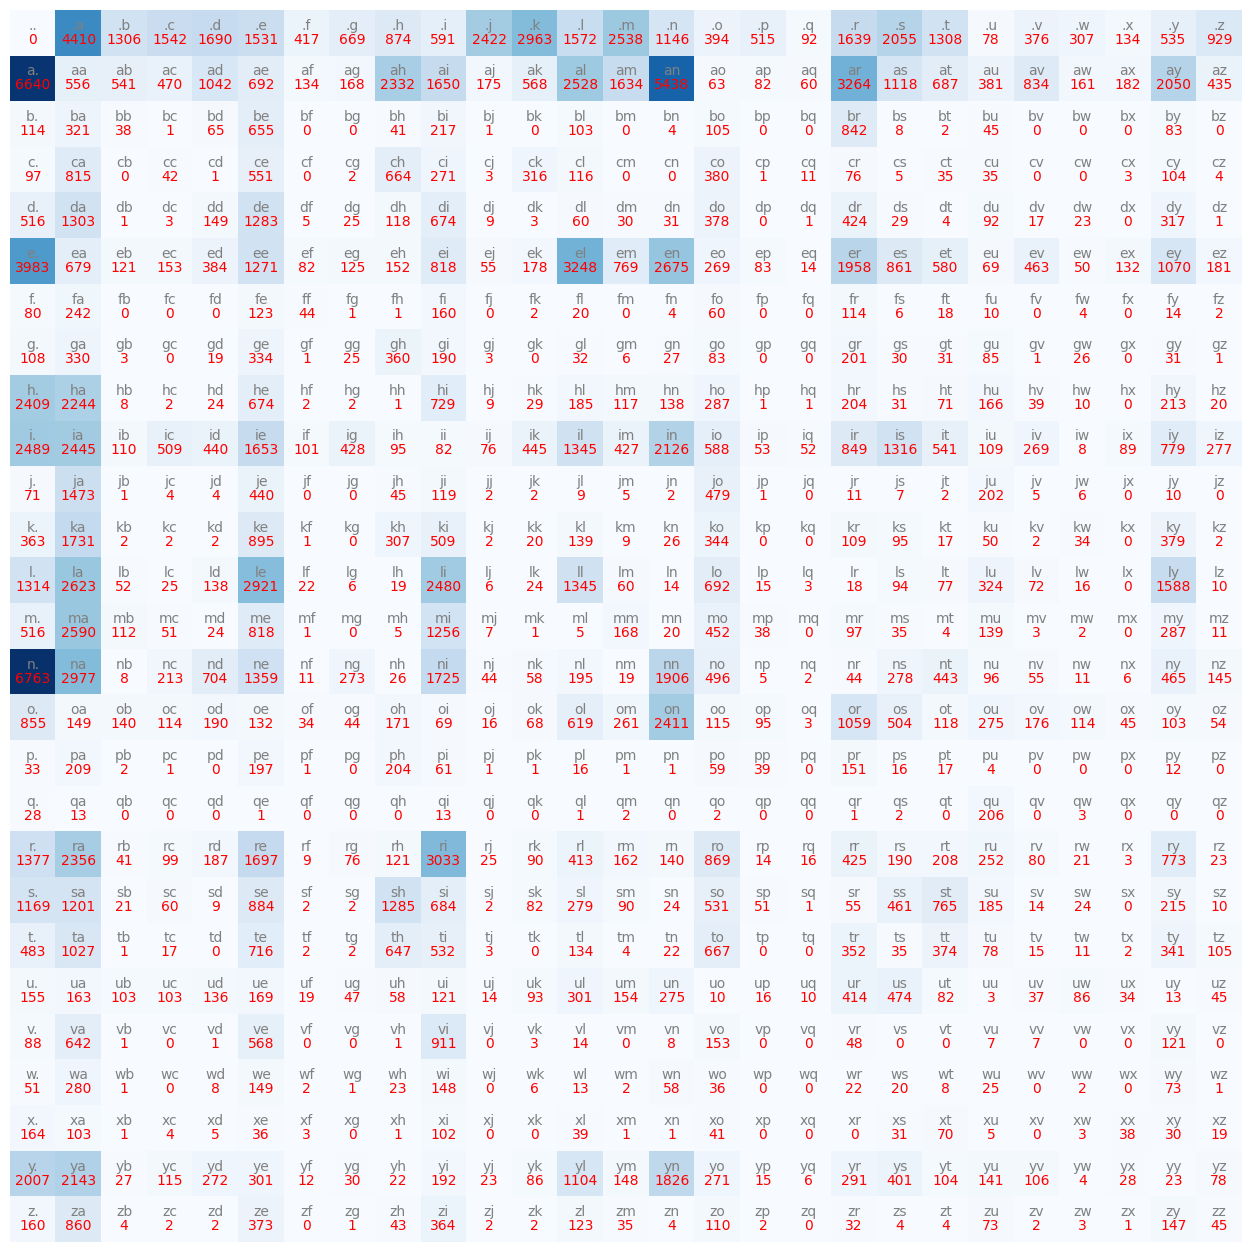

In [107]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

plt.figure(figsize=(16, 16))
plt.imshow(N.tolist(), cmap='Blues')     
for i in range(27):
    for j in range(27):
        plt.text(j, i, itos[i] + itos[j], ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='red')
plt.axis('off')

In [108]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [109]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [110]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

In [111]:
P = N.float()
P = P / P.sum(1, keepdim=True)
P

tensor([[0.0000e+00, 1.3767e-01, 4.0770e-02, 4.8138e-02, 5.2758e-02, 4.7794e-02,
         1.3018e-02, 2.0885e-02, 2.7284e-02, 1.8450e-02, 7.5610e-02, 9.2498e-02,
         4.9074e-02, 7.9231e-02, 3.5776e-02, 1.2300e-02, 1.6077e-02, 2.8720e-03,
         5.1166e-02, 6.4153e-02, 4.0833e-02, 2.4350e-03, 1.1738e-02, 9.5839e-03,
         4.1832e-03, 1.6702e-02, 2.9001e-02],
        [1.9596e-01, 1.6408e-02, 1.5966e-02, 1.3870e-02, 3.0751e-02, 2.0422e-02,
         3.9546e-03, 4.9579e-03, 6.8821e-02, 4.8694e-02, 5.1645e-03, 1.6763e-02,
         7.4605e-02, 4.8222e-02, 1.6048e-01, 1.8592e-03, 2.4199e-03, 1.7707e-03,
         9.6326e-02, 3.2994e-02, 2.0274e-02, 1.1244e-02, 2.4613e-02, 4.7514e-03,
         5.3711e-03, 6.0499e-02, 1.2838e-02],
        [4.3100e-02, 1.2136e-01, 1.4367e-02, 3.7807e-04, 2.4575e-02, 2.4764e-01,
         0.0000e+00, 0.0000e+00, 1.5501e-02, 8.2042e-02, 3.7807e-04, 0.0000e+00,
         3.8941e-02, 0.0000e+00, 1.5123e-03, 3.9698e-02, 0.0000e+00, 0.0000e+00,
         3.1834e-

In [112]:
for i in range(20):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        print(itos[ix], end='')
        if ix == 0:
            break

    print(''.join(out))

exze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


- Now we try to figure out the quality of the model

## Likelihood
- Product of all probablities
- Should be as high as possible
- Since the product of probablity will be a very small value
- So we use log probabilty
- Log probablity is negative and is inversly proportional to probability
- High probability's log nears to 0 and low one's goes more negative


log (a*b*c) = log(a) + log(b) + log(c)

Example log likelihood - 
```
.e: 0.0478 -3.0408
em: 0.0377 -3.2793
mm: 0.0253 -3.6772
ma: 0.3899 -0.9418
a.: 0.1960 -1.6299
.o: 0.0123 -4.3982
ol: 0.0780 -2.5508
li: 0.1777 -1.7278
iv: 0.0152 -4.1867
vi: 0.3541 -1.0383
ia: 0.1381 -1.9796
a.: 0.1960 -1.6299
.a: 0.1377 -1.9829
av: 0.0246 -3.7045
va: 0.2495 -1.3882
a.: 0.1960 -1.6299
Log Likelihood: -38.7856
```

We do not like the log likelihood being negative, since we want to calculate the loss function which we want to reduce. The higher the loss, the worse it is. 

Loss -> Low is good

So we get to negative log likelihood

This is very good since, the lowest it is, is good and the higher the worse. 

For convenience people like to use average of log rather than sum

Goal of the training is to find the parameters that minimise the log likelihood of loss. 

### GOAL: maximize log likelihood of the data wrt. model parameters (statistical modeling)
#### Currently the parameters was the distribution and the probablity table that we built

In [113]:
log_likelihood = 0.0
n = 0

for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logp = torch.log(prob)
        log_likelihood += logp
        n+=1
        print(f'{ch1}{ch2}: {prob:.4f} {logp:.4f}', end='\n')
    
print(f'Log Likelihood: {log_likelihood:.4f}')
nll = -log_likelihood
print(f'Negative Log Likelihood: {nll:.4f}')
print(f'Cross Entropy: {nll/n:.4f}')

.e: 0.0478 -3.0408
em: 0.0377 -3.2793
mm: 0.0253 -3.6772
ma: 0.3899 -0.9418
a.: 0.1960 -1.6299
.o: 0.0123 -4.3982
ol: 0.0780 -2.5508
li: 0.1777 -1.7278
iv: 0.0152 -4.1867
vi: 0.3541 -1.0383
ia: 0.1381 -1.9796
a.: 0.1960 -1.6299
.a: 0.1377 -1.9829
av: 0.0246 -3.7045
va: 0.2495 -1.3882
a.: 0.1960 -1.6299
Log Likelihood: -38.7856
Negative Log Likelihood: 38.7856
Cross Entropy: 2.4241


## Loss for a particular word

In [114]:
log_likelihood = 0.0
n = 0

for w in ['andrej']:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logp = torch.log(prob)
        log_likelihood += logp
        n+=1
        print(f'{ch1}{ch2}: {prob:.4f} {logp:.4f}', end='\n')
    
print(f'Log Likelihood: {log_likelihood:.4f}')
nll = -log_likelihood
print(f'Negative Log Likelihood: {nll:.4f}')
print(f'Cross Entropy: {nll/n:.4f}')

.a: 0.1377 -1.9829
an: 0.1605 -1.8296
nd: 0.0384 -3.2594
dr: 0.0771 -2.5620
re: 0.1336 -2.0127
ej: 0.0027 -5.9171
j.: 0.0245 -3.7098
Log Likelihood: -21.2735
Negative Log Likelihood: 21.2735
Cross Entropy: 3.0391


For a combination with 0 probability will cause the ll to be 0
Which is a problem

So we do model smoothening

Add a count of X (a positive integer) to everything in N

## Next steps

Alternative approach, cast logic of bigrams into neural network framework

### Our NN - 
- Still a bigram
- Recieves a simple character as an input
- Output the prob distribution over the next character in the sequence
- Evaluate any setting of the parameters of the NN

### NN training - 
- Gradient Based Optimisation to tune the parameters of the network
- Minimise the loss function


### Steps
1. Create the training set of all the bigrams

## Step 1: Create the training set of all the bigrams

In [115]:
xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)


xs = torch.tensor(xs)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [116]:
xs

tensor([ 0,  5, 13, 13,  1])

In [117]:
ys

tensor([ 5, 13, 13,  1,  0])

## One hot encoding
- Converts inputs into vectors where every value is 0 except the index of our value being set to 1

In [118]:
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).float()
xenc.shape

torch.Size([5, 27])

In [119]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.


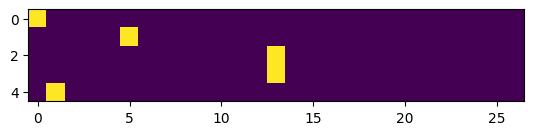

In [120]:
plt.imshow(xenc)

## Construct first neuron

- Performs wx + b

### Steps
1. Initialise the weights of the neuron (randomly)

In [127]:
W = torch.randn((27, 27)) # 27 input features, 27 output features (neurons) (logits for each possible next character)
logits = xenc @ W # log counts

In [128]:
W

tensor([[ 9.5519e-01, -6.3504e-01,  1.1348e-01,  2.6028e-01,  1.1728e-02,
         -1.0866e+00,  6.4714e-01, -4.9098e-01, -3.3856e-01,  1.0274e+00,
          1.3866e+00,  1.2427e+00, -1.1485e+00,  1.1142e+00, -1.2496e+00,
         -4.1376e-01, -3.8042e-01,  3.6832e-01,  9.6991e-02, -1.5004e+00,
         -5.1077e-01,  6.2083e-02, -6.5706e-01,  1.1105e+00, -1.8426e+00,
          4.2979e-01,  9.2435e-01],
        [-9.9925e-01, -4.7979e-01, -1.3341e+00,  4.2632e-01,  6.7905e-01,
          6.5568e-01,  1.1655e+00, -1.1682e+00, -1.3768e+00, -1.0300e+00,
         -8.1113e-01, -2.5488e-02,  2.7195e+00, -1.3777e+00, -1.1123e+00,
         -3.1125e+00, -1.1620e+00, -1.3736e-01,  1.4961e+00,  2.1853e+00,
          1.1596e+00,  3.0474e-01, -1.5491e+00,  2.8952e-01, -1.5280e+00,
         -2.2187e-01,  9.9251e-01],
        [-1.9006e+00,  5.2777e-01,  1.3214e+00, -1.1210e+00,  1.0987e+00,
         -1.7848e+00, -5.7776e-01,  1.3012e+00,  1.0927e+00,  6.3949e-01,
          1.1269e-02,  1.4608e+00,  1.74

In [129]:
logits

tensor([[ 0.9552, -0.6350,  0.1135,  0.2603,  0.0117, -1.0866,  0.6471, -0.4910,
         -0.3386,  1.0274,  1.3866,  1.2427, -1.1485,  1.1142, -1.2496, -0.4138,
         -0.3804,  0.3683,  0.0970, -1.5004, -0.5108,  0.0621, -0.6571,  1.1105,
         -1.8426,  0.4298,  0.9243],
        [-0.7648, -1.2461, -1.1893, -1.0526, -0.3427, -0.4289, -0.6786, -0.6358,
          0.5169,  0.5031,  1.8684, -1.0018, -1.7589,  0.6653, -0.9767, -0.1961,
          0.7466,  0.4602, -0.0490,  1.4451, -0.1034, -0.7959, -1.4434,  1.8076,
          0.1260, -1.3485, -0.6661],
        [ 0.6389,  1.1402,  1.5328, -0.2126,  1.9037,  0.6769, -0.9715,  1.0507,
          0.2005, -0.9951,  1.1544,  1.0963,  1.0560,  0.2993,  0.4649, -0.2349,
          1.2078,  1.8835,  0.9648,  0.2989, -1.4279,  1.4654,  1.0724,  0.0582,
         -1.1801, -1.3305,  0.9083],
        [ 0.6389,  1.1402,  1.5328, -0.2126,  1.9037,  0.6769, -0.9715,  1.0507,
          0.2005, -0.9951,  1.1544,  1.0963,  1.0560,  0.2993,  0.4649, -0.2349

- What we have right now in the weights is just some negative and positive numbers
- But what we want is something that matches our bigram model, which had the probabilities
- Probabilities are positive numbers that sum to 1
- And the table N had counts, which we can't do with the NN
- So we will consider the NN to give us log counts
- So we can do exp on the dot product 

- Exponentiated numbers give us something we can treat as counts (distribution)

### This is called Softmax
- Takes in logits
- Exponentiates them
- Divides and normalises

In [130]:
counts = logits.exp() # Similar to the N array above
probs = counts / counts.sum(1, keepdim=True) # Similar to the P array above
probs

tensor([[0.0691, 0.0141, 0.0298, 0.0345, 0.0269, 0.0090, 0.0508, 0.0163, 0.0190,
         0.0743, 0.1064, 0.0922, 0.0084, 0.0811, 0.0076, 0.0176, 0.0182, 0.0384,
         0.0293, 0.0059, 0.0160, 0.0283, 0.0138, 0.0808, 0.0042, 0.0409, 0.0670],
        [0.0130, 0.0080, 0.0085, 0.0098, 0.0198, 0.0182, 0.0142, 0.0148, 0.0469,
         0.0462, 0.1811, 0.0103, 0.0048, 0.0544, 0.0105, 0.0230, 0.0590, 0.0443,
         0.0266, 0.1186, 0.0252, 0.0126, 0.0066, 0.1704, 0.0317, 0.0073, 0.0144],
        [0.0304, 0.0502, 0.0744, 0.0130, 0.1078, 0.0316, 0.0061, 0.0459, 0.0196,
         0.0059, 0.0510, 0.0481, 0.0462, 0.0217, 0.0256, 0.0127, 0.0538, 0.1057,
         0.0422, 0.0217, 0.0039, 0.0696, 0.0470, 0.0170, 0.0049, 0.0042, 0.0398],
        [0.0304, 0.0502, 0.0744, 0.0130, 0.1078, 0.0316, 0.0061, 0.0459, 0.0196,
         0.0059, 0.0510, 0.0481, 0.0462, 0.0217, 0.0256, 0.0127, 0.0538, 0.1057,
         0.0422, 0.0217, 0.0039, 0.0696, 0.0470, 0.0170, 0.0049, 0.0042, 0.0398],
        [0.0070, 0.0118,

In [131]:
nlls = torch.zeros(5)

for i in range(5): 
    x = xs[i].item() # input character index
    y = ys[i].item() # target character index
    print('\n--------------------------------\n')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x}, {y})')
    print(f'input to the neural network: {itos[x]}')
    print(f'output probabilities of the neural network: {probs[i]}')
    print(f'label (actual next character): {itos[y]}')
    p = probs[i, y]
    print(f'probability of the correct next character according to the neural network: {p:.4f}')
    logp = torch.log(p)
    print(f'log probability of the correct next character according to the neural network: {logp:.4f}')
    nll = -logp
    print(f'negative log likelihood loss for this bigram: {nll:.4f}')
    nlls[i] = nll

print('--------------------------------')
print(f'average negative log likelihood loss across the 5 bigrams: {nlls.mean():.4f}')


--------------------------------

bigram example 1: .e (indexes 0, 5)
input to the neural network: .
output probabilities of the neural network: tensor([0.0691, 0.0141, 0.0298, 0.0345, 0.0269, 0.0090, 0.0508, 0.0163, 0.0190,
        0.0743, 0.1064, 0.0922, 0.0084, 0.0811, 0.0076, 0.0176, 0.0182, 0.0384,
        0.0293, 0.0059, 0.0160, 0.0283, 0.0138, 0.0808, 0.0042, 0.0409, 0.0670])
label (actual next character): e
probability of the correct next character according to the neural network: 0.0090
log probability of the correct next character according to the neural network: -4.7134
negative log likelihood loss for this bigram: 4.7134

--------------------------------

bigram example 2: em (indexes 5, 13)
input to the neural network: e
output probabilities of the neural network: tensor([0.0130, 0.0080, 0.0085, 0.0098, 0.0198, 0.0182, 0.0142, 0.0148, 0.0469,
        0.0462, 0.1811, 0.0103, 0.0048, 0.0544, 0.0105, 0.0230, 0.0590, 0.0443,
        0.0266, 0.1186, 0.0252, 0.0126, 0.0066, 0.1

## Why/How can we say that our way of calculating the quality of our NN is good
The benchmark that tells us a "high" negative log likelihood (NLL) is bad is **pure randomness** (a completely uniform distribution).

When you start training a neural network on a dataset like the names file in *micrograd* / *makemore*, the absolute baseline of "cluelessness" gives us an exact, mathematically derived NLL score. Anything significantly higher than or equal to that number means the network is performing no better than a monkey throwing darts at an alphabet board.

Here is exactly how that baseline is calculated and used as the ultimate benchmark.

---

### 1. The "Completely Random" Baseline (The Worst-Case Benchmark)

In the bigram model example, we are trying to predict the next character out of a specific vocabulary. Let's look at the numbers Karpathy uses:

* The alphabet has **26 letters**.
* Plus **1 special token** (the `.` character used for start/end).
* Total vocabulary size ($V$) = **27 possible tokens**.

If a neural network has completely random weights and hasn't learned *anything* yet, it will assign an equal probability to every single character. The probability ($P$) of guessing the correct next character by pure luck is:

$$P = \frac{1}{27} \approx 0.037 \text{ (or } 3.7\% \text{)}$$

Now, let's calculate the Negative Log Likelihood for that pure-chance guess. The formula for NLL for a single prediction is $-\ln(P)$:

$$\text{Baseline NLL} = -\ln\left(\frac{1}{27}\right) \approx 3.2958$$

#### The Rule of Thumb

* **NLL $\approx 3.3$:** The model is completely guessing. It has learned absolutely nothing.
* **NLL $> 3.3$:** The model is actually *worse* than random guessing. This usually means the model is confidently wrong (e.g., predicting a 0% chance for a character that actually happens).
* **NLL $< 3.3$:** The model is starting to learn patterns. The lower this number goes, the better.

---

### 2. The Bigram Counting Baseline (The Best-Case Bigram Benchmark)

On the flip side, what is the *best* a bigram model could possibly do?

Before building the neural network, Karpathy calculates a simple **count-based bigram matrix** (where you literally just count how often letter `X` is followed by letter `Y` in the dataset, add 1 for smoothing, and normalize it into probabilities).

Because a bigram model *only* looks at the single current character to predict the next one, a counting matrix provides the absolute mathematical limit of how much information a bigram window can extract from that text.

When you calculate the NLL of that explicit counting matrix on the training data, you get:


$$\text{Perfect Bigram NLL} \approx 2.454$$

### The Spectrum of Success

This gives you a beautifully defined tight window to evaluate your neural network:

```text
  [ Worst-Case ]                                      [ Best-Case Bigram ]
  Pure Randomness                                      Counting Matrix
     NLL = 3.30                                          NLL = 2.454
         |---------------------------------------------------|
         ▼                                                   ▼
  (Network starts here)                               (Network targets this)

```

* If your neural network achieves an NLL of **2.45**, your weights and optimization (gradient descent) worked perfectly. It has fully extracted all possible bigram dynamics out of the data.
* To get an NLL *lower* than 2.45, you have to abandon the bigram constraint entirely and move to a **trigram** model (looking at 2 characters of context) or a larger transformer context window, because a single-character history physically contains no more information to give.

## Train the NN
- Use the gradient for the weights to improve the values of the weights to reduce the negative log likelihood. 
- We will do what we did in micrograd

In [132]:
# randomly initialize the weights of the neural network with a fixed seed for reproducibility
# 27 neurons' weights. Each neuron has 27 weights corresponding to the 27 input features (characters)
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True) # 27 input features, 27 output features (neurons) (logits for each possible next character)

In [133]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp() # Similar to the N array above
probs = counts / counts.sum(1, keepdim=True) # Similar to the P array above
loss = -probs[torch.arange(5), ys].log().mean()
loss

tensor(3.7693, grad_fn=<NegBackward0>)

## Why the log counts -> counts -> Prob -> Likelihood -> Log Likelihood -> Negative Log Likelihood is not a loop
 
It absolutely looks like a loop at first glance: you take a raw number, exponentiate it, divide it to normalize, and then immediately slap a logarithm back onto it.

But it isn't a perfect loop because of **one crucial mathematical operation** that happens right in the middle: **normalization**.

The exponentiation creates *independent* positive numbers, but the normalization forces them to *compete* with each other. Because of that step, taking the log at the end doesn't just undo the exponent; it measures how well a specific character performed relative to all the other choices.

Here is the step-by-step breakdown of why this "loop" is actually a filter that extracts relative probabilities.

---

### The Forward Pass (Logits to Loss)

Let's trace a single character prediction. Say your network outputs raw, unnormalized log-counts (called **logits**). For a specific history, let's say the network outputs three numbers for a mini-alphabet of A, B, and C:


$$\text{Logits} = [2.0, 1.0, 0.0]$$

If the actual target character in the training data is **A**, here is what happens:

#### Step 1: Exponentiate (To get "counts")

We exponentiate ($e^x$) to turn negative or positive logits into strictly positive "counts".

* $e^{2.0} \approx 7.39$
* $e^{1.0} \approx 2.72$
* $e^{0.0} = 1.00$

#### Step 2: Normalize (The "Loop Breaker")

To make these counts a valid probability distribution, we sum them up ($\sum = 7.39 + 2.72 + 1.00 = 11.11$) and divide each by that sum. This is the **Softmax** function.

* $P(A) = \frac{7.39}{11.11} \approx 0.665$
* $P(B) = \frac{2.72}{11.11} \approx 0.245$
* $P(C) = \frac{1.00}{11.11} \approx 0.090$

#### Step 3: Log-Likelihood and Negative Loss

Now we evaluate our target character (**A**) by taking the negative log of its probability:


$$\text{Loss} = -\ln(P(A)) = -\ln(0.665) \approx 0.408$$

---

### Looking under the hood: The Algebra

If you write this entire sequence out as a single algebraic formula for our target character $A$, the "loop" structure reveals why it doesn't just cancel out:

$$\text{Loss} = -\ln \left( \frac{e^{\text{logit}_A}}{e^{\text{logit}_A} + e^{\text{logit}_B} + e^{\text{logit}_C}} \right)$$

Using the logarithmic identity $\ln(\frac{x}{y}) = \ln(x) - \ln(y)$, we can expand this:

$$\text{Loss} = -\left[ \ln(e^{\text{logit}_A}) - \ln(e^{\text{logit}_A} + e^{\text{logit}_B} + e^{\text{logit}_C}) \right]$$

Now, the $\ln(e^x)$ **does** cancel out for the first term! Let's simplify and distribute the negative sign:

$$\text{Loss} = -\text{logit}_A + \ln(e^{\text{logit}_A} + e^{\text{logit}_B} + e^{\text{logit}_C})$$

### Why this is beautiful for Gradients

Look at that final simplified equation. The loss is split into two forces acting on the network:

1. **$-\text{logit}_A$**: This wants to push the raw score of the correct answer **up** as high as possible to decrease the total loss.
2. **$\ln(\sum e^{\text{logits}})$**: This is a penalty term. It acts like a soft maximum of *all* the logits combined. It wants to pull the scores of **all** characters down.

So, while the exponent and the log structurally dance around each other, the math works out so that during backpropagation, the gradient simplifies beautifully. It results in a very elegant training signal: **(Predicted Probability - Target Probability)**.

Without that exponentiation step at the beginning, we wouldn't be able to calculate gradients cleanly when dealing with negative raw neural network outputs!

In [134]:
# backward pass
W.grad = None # set to zero the gradient
loss.backward()

In [135]:
W.grad

tensor([[ 0.0121,  0.0020,  0.0025,  0.0008,  0.0034, -0.1975,  0.0005,  0.0046,
          0.0027,  0.0063,  0.0016,  0.0056,  0.0018,  0.0016,  0.0100,  0.0476,
          0.0121,  0.0005,  0.0050,  0.0011,  0.0068,  0.0022,  0.0006,  0.0040,
          0.0024,  0.0307,  0.0292],
        [-0.1970,  0.0017,  0.0079,  0.0020,  0.0121,  0.0062,  0.0217,  0.0026,
          0.0025,  0.0010,  0.0205,  0.0017,  0.0198,  0.0022,  0.0046,  0.0041,
          0.0082,  0.0016,  0.0180,  0.0106,  0.0093,  0.0062,  0.0010,  0.0066,
          0.0131,  0.0101,  0.0018],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000

In [136]:
W.data += -0.1 * W.grad

## Collecting it together

In [137]:
# create the dataset
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)


xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ',  num)

# initialize the network
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True) # 27 input features, 27 output features (neurons) (logits for each possible next

number of examples:  228146


In [138]:
# gradient descent loop
for k in range(1000):
    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp() # Similar to the N array above
    probs = counts / counts.sum(1, keepdim=True) # Similar to the P array above
    loss = -probs[torch.arange(num), ys].log().mean() + ((W**2).mean() * 0.01)
    
    # backward pass
    W.grad = None # set to zero the gradient
    loss.backward()
    
    # update weights using gradient descent
    W.data += -100 * W.grad
    
    if k % 100 == 0:
        print(f'iteration {k}, loss: {loss.item():.4f}')

iteration 0, loss: 3.7686
iteration 100, loss: 2.5114
iteration 200, loss: 2.5095
iteration 300, loss: 2.5091
iteration 400, loss: 2.5090
iteration 500, loss: 2.5090
iteration 600, loss: 2.5089
iteration 700, loss: 2.5089
iteration 800, loss: 2.5089
iteration 900, loss: 2.5089


## What does a layer of 27 neurons with each having 27 inputs signify in the makemore bigram NN 

In the *makemore* bigram neural network, a layer of **27 neurons where each neuron has 27 inputs** represents a complete, look-up transition table of probabilities from every possible character to every possible next character.

It is literally a neural network masquerading as a $27 \times 27$ grid (or matrix).

Here is exactly how the inputs, neurons, and weights map to the concept of a bigram.

---

### The Architecture Map

To understand what this layer signifies, look at how data flows through it:

* **The 27 Inputs:** This is a **one-hot encoded vector** representing the *current* character. If the current character is 'a' (the first character in our 27-token alphabet), the input vector is a `1` at index 0 and `0` everywhere else: `[1, 0, 0, ..., 0]`.
* **The 27 Neurons:** Each individual neuron is dedicated to predicting the likelihood of **one specific next character**. Neuron 0 predicts how likely the next character is to be `.`, Neuron 1 predicts 'a', Neuron 2 predicts 'b', and so on.

---

### The Secret: One-Hot Matrix Multiplication

Because the input is a one-hot vector (a single `1` and twenty-six `0`s), the standard neural network math ($y = xW + b$) does something very specific.

When you multiply that one-hot input vector by the $27 \times 27$ weight matrix of the layer, the `0`s completely zero out 26 rows of the matrix. The single `1` acts like an index pointer that pulls out **exactly one specific row** of weights.

```text
Input ('a')         Weight Matrix (27x27)             Output Logits
                  .   a   b   c  ...
[1, 0, 0, ...] × [ 2.1, 0.4, -1.2, ... ] (Row 0: 'a')  =  [2.1, 0.4, -1.2, ...]
                 [ -0.5, 1.1,  0.2, ... ] (Row 1: 'b')
                 [  0.0, 0.1,  3.4, ... ] (Row 2: 'c')

```

### What the Weights Signify

Because of this lookup mechanism, each of the $27 \times 27 = 729$ weights in that layer has a precise semantic meaning:

> **The weight at $W[i][j]$ signifies the raw, unnormalized log-count (logit) of character $i$ being followed by character $j$.**

* **The Inputs** select *which* row of the table we are looking at (the context character).
* **The Neurons** represent the columns of the table (the potential next characters).

### Summary: It’s a Differentiable Count Table

In the first part of *makemore*, Karpathy builds an explicit $27 \times 27$ counting matrix by just looping through the text and adding up pairs.

This $27 \times 27$ single-layer neural network is doing **the exact same thing**, but instead of counting explicitly, it initializes those 729 positions with random numbers (weights) and uses gradient descent to tweak them until they mirror the real log-probabilities of the dataset.

In [139]:
# finally, let's sample from the model to generate new names
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float() # encode the current character index as one-hot
        logits = xenc @ W # compute logits for the next character
        counts = logits.exp() # convert logits to counts
        probs = counts / counts.sum(1, keepdim=True) # convert counts to probabilities
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item() # sample the next character index
        out.append(itos[ix]) # append the corresponding character to the output list
        if ix == 0: # if we sampled the end character, stop
            break

    print(''.join(out))

cexze.
momanurailezityharellimittain.
llayn.
kanar.
staiyaubrtthrigotai.
